<a href="https://colab.research.google.com/github/Dexter0013/Deepraj-Singha-6th-Sem-CSE-Data-Mining-Assignments/blob/main/1.%20Digit%20Recognition%20using%20MNIST%20Dataset/Digit_Recognition_using_mnist_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Load all the required libraries and perform Preprocessing on MNIST dataset**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape data to include the channel dimension (28, 28, 1)
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(f"Training images: {x_train.shape}")
print(f"Testing images: {x_test.shape}")
print(f"Pixel range: {x_train.min()} to {x_train.max()}")

Training images: (60000, 28, 28, 1)
Testing images: (10000, 28, 28, 1)
Pixel range: 0.0 to 1.0


**Step 2: Defining and training the CNN model**

In [ ]:
# Build the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
print("Training the model...")
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_test, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the model...
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9563 - loss: 0.1453 - val_accuracy: 0.9835 - val_loss: 0.0526
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9856 - loss: 0.0475 - val_accuracy: 0.9861 - val_loss: 0.0398
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9896 - loss: 0.0326 - val_accuracy: 0.9908 - val_loss: 0.0284
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9926 - loss: 0.0240 - val_accuracy: 0.9907 - val_loss: 0.0301
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9940 - loss: 0.0184 - val_accuracy: 0.9923 - val_loss: 0.0295
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9954 - loss: 0.0134 - val_accuracy: 0.9913 - val_loss: 0.0299
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9966 - loss: 0.0111 - val_accuracy: 0.9917 - val_loss: 0.0299
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy

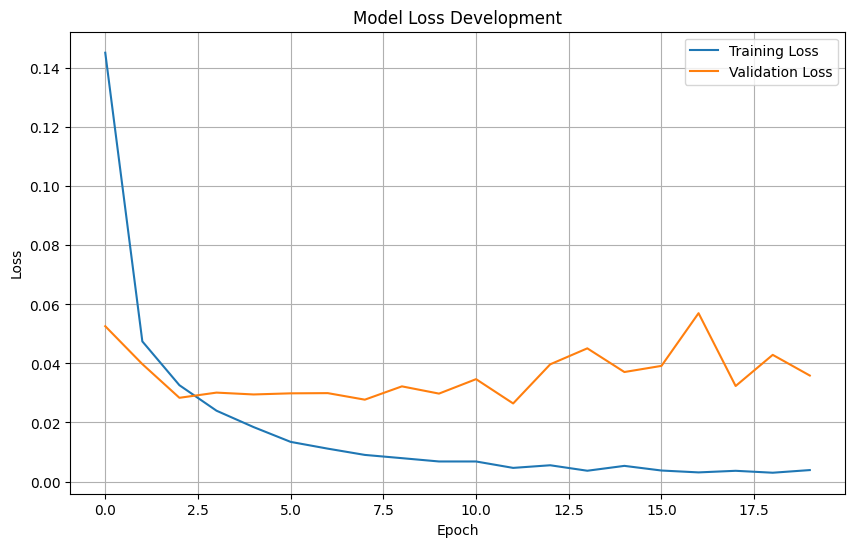

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Development')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

**Step 2.1: Save the Model after training**

In [ ]:
import tensorflow as tf

# Save the entire model to a HDF5 file or the native Keras format
model.save('mnist_cnn_model.keras')
print("Model saved to mnist_cnn_model.keras")

Model saved to mnist_cnn_model.keras


**Step 2.2: Loading the Saved Model**

In [ ]:
loaded_model = tf.keras.models.load_model('mnist_cnn_model.keras')
print("Model loaded successfully")

Model loaded successfully


**Step 3: Plotting the confusion Matrix**

Generating predictions...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


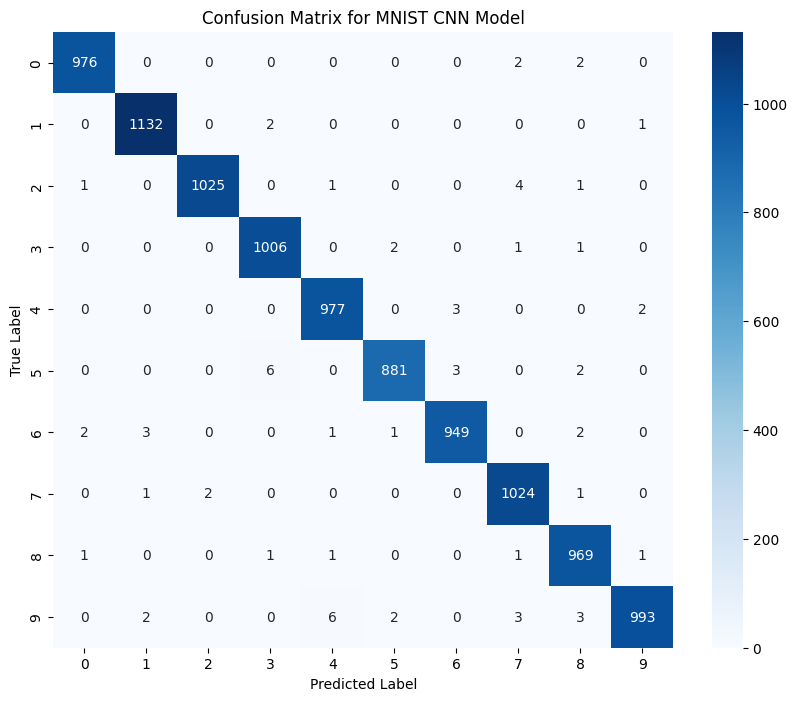

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# predictions are generated before plotting
print("Generating predictions...")
predictions = model.predict(x_test)

# Get the predicted classes for the test set
y_pred = np.argmax(predictions, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Ploting the confusion matrix using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for MNIST CNN Model')
plt.show()

**Step 4: Prediction using the model | | loaded_model**

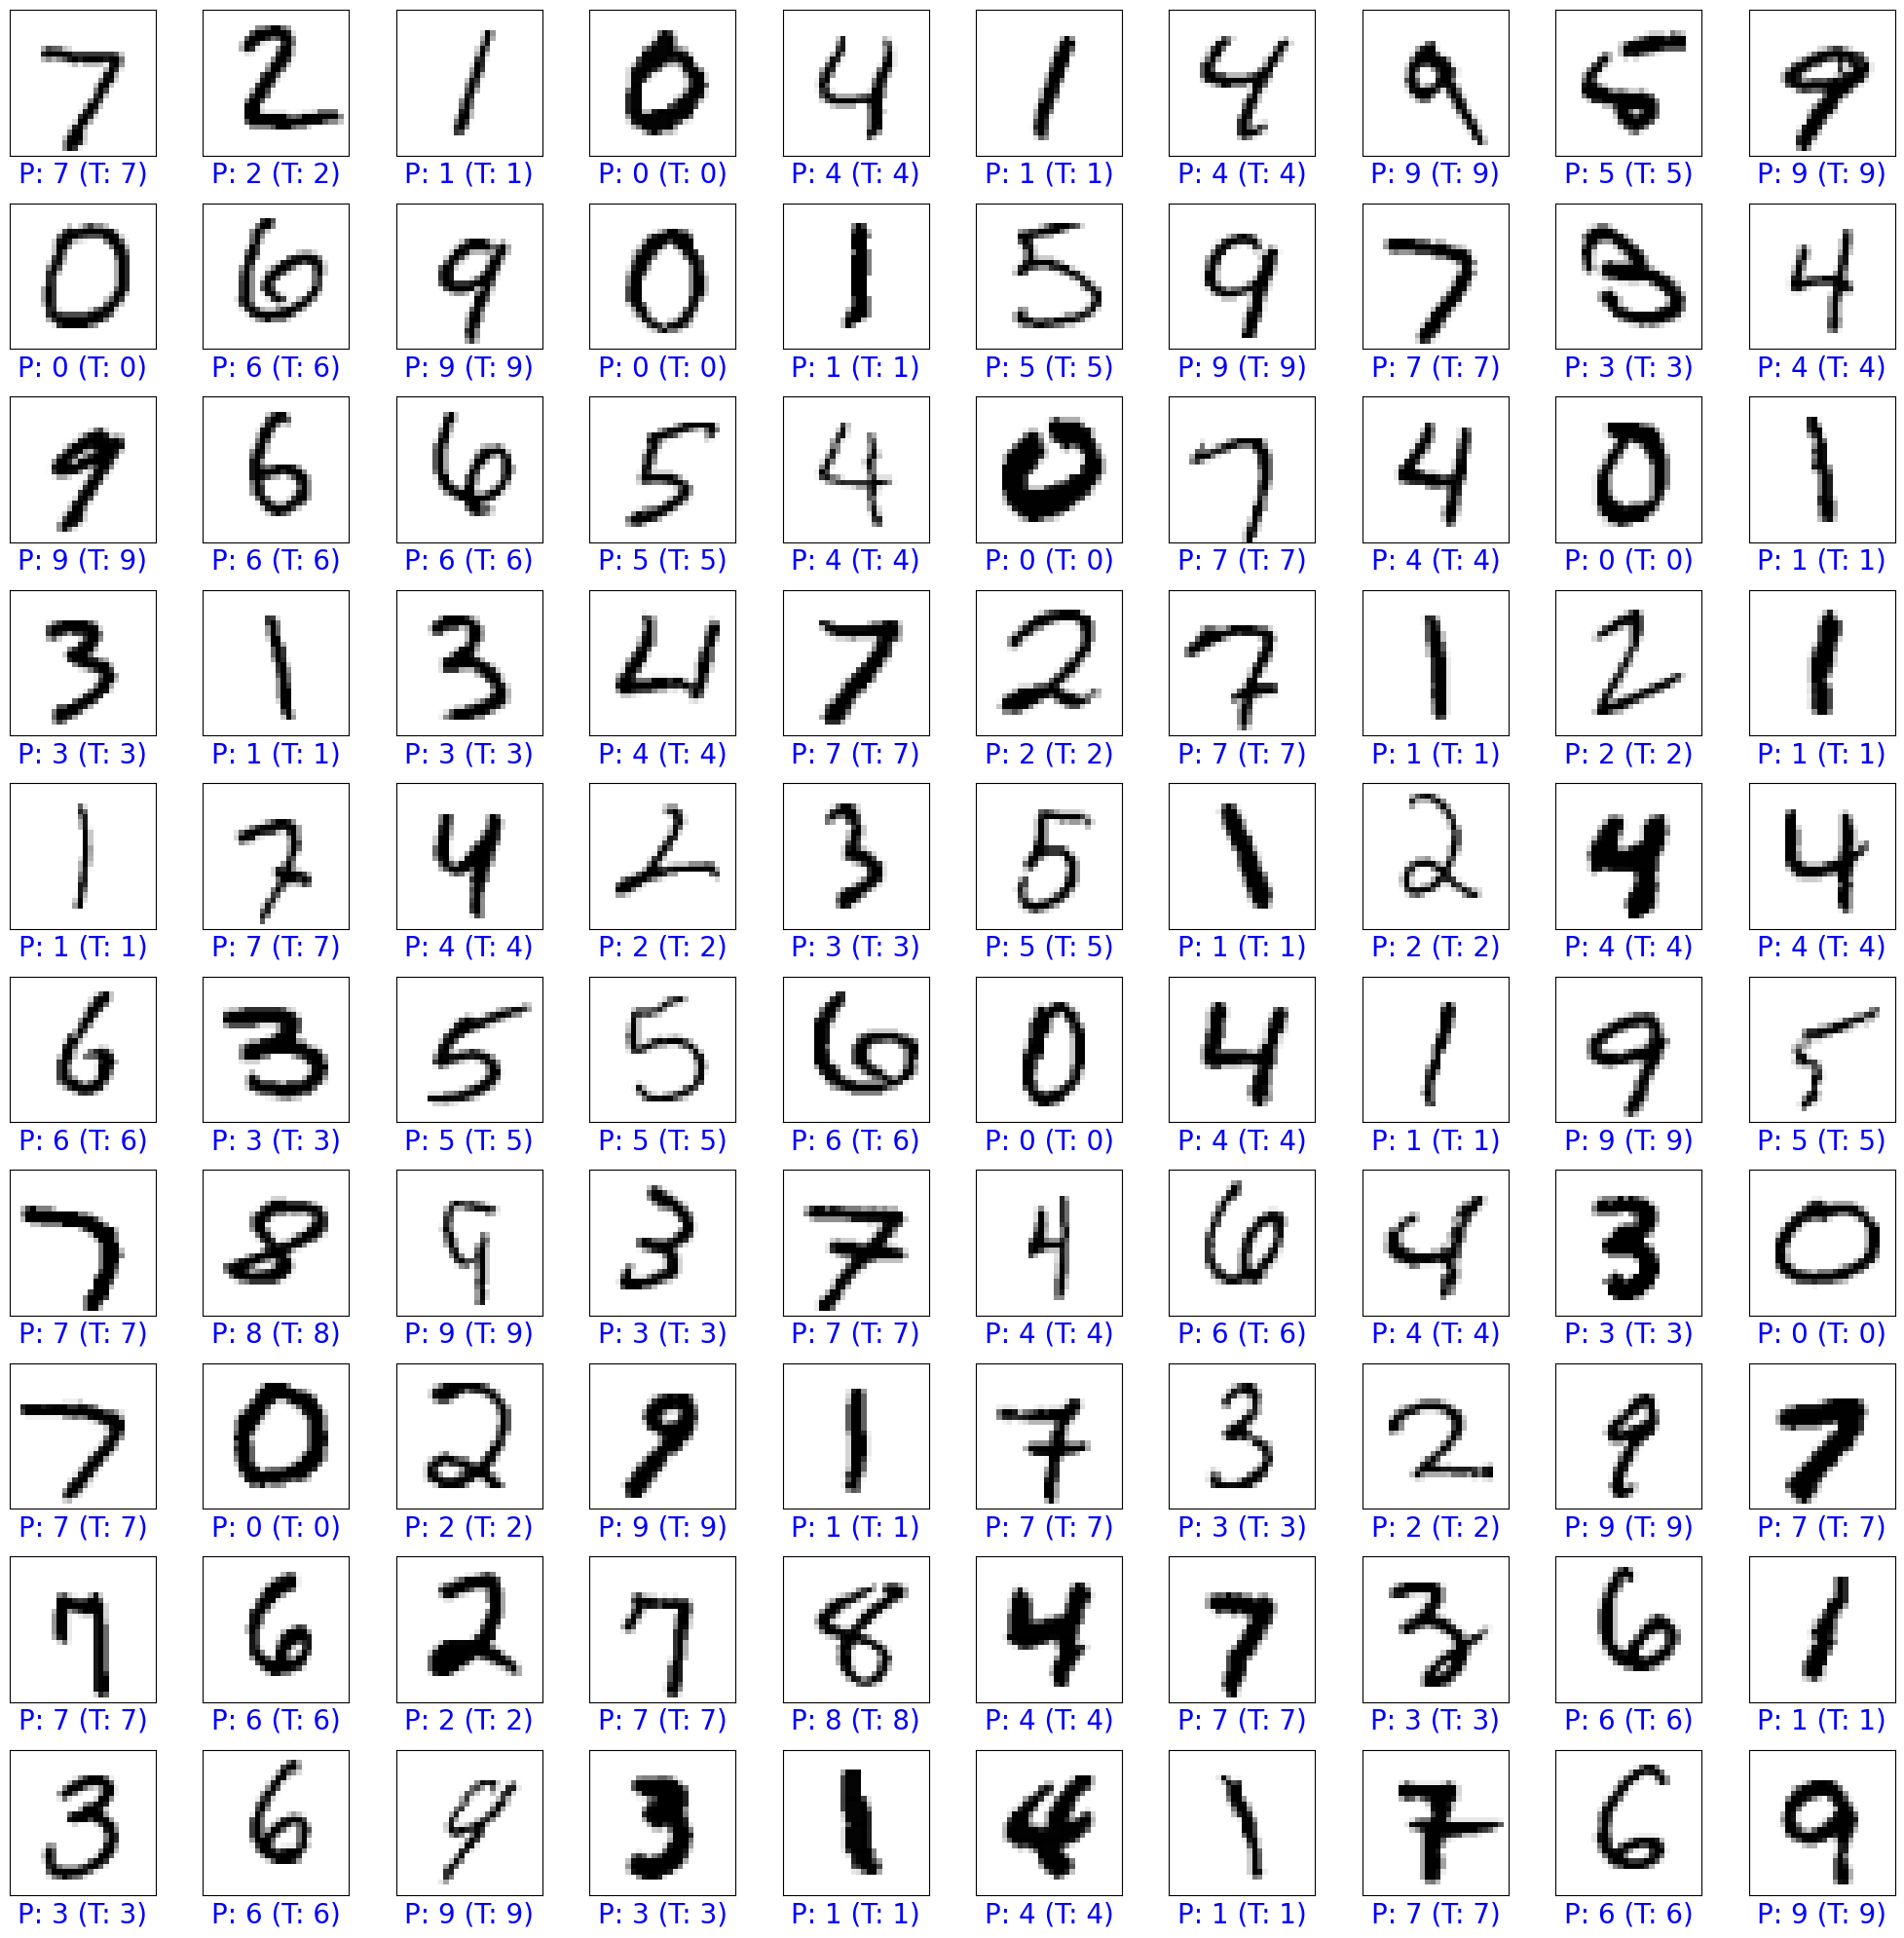

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize 100 results in a readable 10x10 grid
plt.figure(figsize=(20, 20))
for i in range(100):
    plt.subplot(10, 10, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i].reshape(28, 28), cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i]

    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"P: {predicted_label} (T: {true_label})", color=color, fontsize=20)

plt.tight_layout()
plt.show()